In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os

## Pretraining

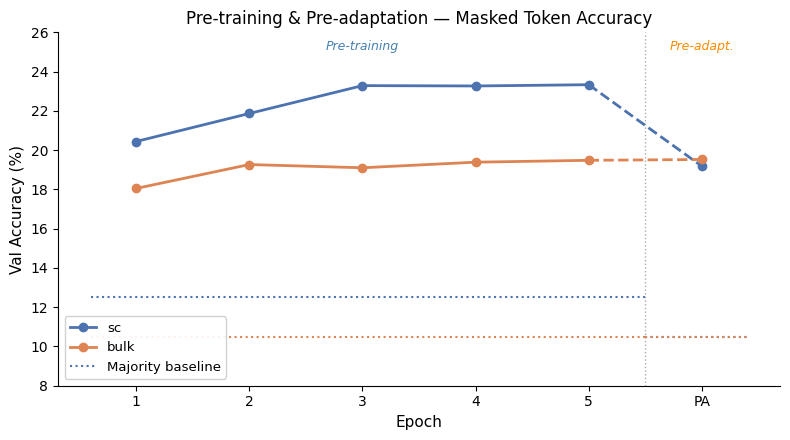

In [63]:
root = os.path.expanduser("~/Thesis/eheiss/output")

def load_val(path):
    df = pd.read_csv(path)
    return df[df["split"] == "val"].reset_index(drop=True)

pt_sc   = load_val(f"{root}/pretrain_sc/pretrain_sc_pretrain_epoch_metrics.csv")
pt_bulk = load_val(f"{root}/pretrain_bulk/pretrain_bulk_pretrain_epoch_metrics.csv")
pa_sc   = load_val(f"{root}/preadapt_sc/preadapt_sc_pretrain_epoch_metrics.csv")
pa_bulk = load_val(f"{root}/preadapt_bulk/preadapt_bulk_pretrain_epoch_metrics.csv")

pretrain_x = list(pt_sc["epoch"])
preadapt_x = [pretrain_x[-1] + 1]
sep = (pretrain_x[-1] + preadapt_x[0]) / 2

sc_color   = "#4C72B0"
bulk_color = "#DD8452"

fig, ax = plt.subplots(figsize=(8, 4.5))

# pretrain lines
ax.plot(pretrain_x, pt_sc["accuracy"],   color=sc_color,   marker="o", lw=2, zorder=3, label="sc")
ax.plot(pretrain_x, pt_bulk["accuracy"], color=bulk_color, marker="o", lw=2, zorder=3, label="bulk")

# dashed connectors + preadapt dots
for df_pt, df_pa, color in [(pt_sc, pa_sc, sc_color), (pt_bulk, pa_bulk, bulk_color)]:
    ax.plot([pretrain_x[-1], preadapt_x[0]],
            [df_pt["accuracy"].iloc[-1], df_pa["accuracy"].iloc[0]],
            color=color, lw=2, ls="--", zorder=3)
    ax.plot(preadapt_x, [df_pa["accuracy"].iloc[0]], color=color, marker="o", lw=2, zorder=3)

# majority baselines — dotted, in corresponding color
maj_sc_pt   = pt_sc["majority_baseline_accuracy"].iloc[0]
maj_bulk_pt = pt_bulk["majority_baseline_accuracy"].iloc[0]
maj_sc_pa   = pa_sc["majority_baseline_accuracy"].iloc[0]
maj_bulk_pa = pa_bulk["majority_baseline_accuracy"].iloc[0]

x0, x1, x2 = pretrain_x[0] - 0.4, sep, preadapt_x[0] + 0.4
ax.hlines(maj_sc_pt,   x0, x1, color=sc_color,   ls=":", lw=1.5, label="Majority baseline", zorder=2)
ax.hlines(maj_bulk_pt, x0, x1, color=bulk_color, ls=":", lw=1.5, zorder=2)
ax.hlines(maj_sc_pa,   x1, x2, color=sc_color,   ls=":", lw=1.5, zorder=2)
ax.hlines(maj_bulk_pa, x1, x2, color=bulk_color, ls=":", lw=1.5, zorder=2)

# phase separator
ax.axvline(sep, color="#aaaaaa", ls=":", lw=1)

# phase labels
y_lo, y_hi = 8, 26
ax.text(np.mean(pretrain_x), y_hi - 0.4, "Pre-training",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text(preadapt_x[0], y_hi - 0.4, "Pre-adapt.",
        ha="center", va="top", fontsize=9, color="darkorange", style="italic")

ax.set_ylim(y_lo, y_hi)
ax.set_xticks(pretrain_x + preadapt_x)
ax.set_xticklabels([str(e) for e in pretrain_x] + ["PA"])
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Val Accuracy (%)", fontsize=11)
ax.set_title("Pre-training & Pre-adaptation — Masked Token Accuracy", fontsize=12)
ax.legend(loc="lower left", fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Cancer classification (5 types)

In [48]:
bulkrnabert_weighted_f1_mean = 0.993
bulkrnabert_weighted_f1_sd = 0.004

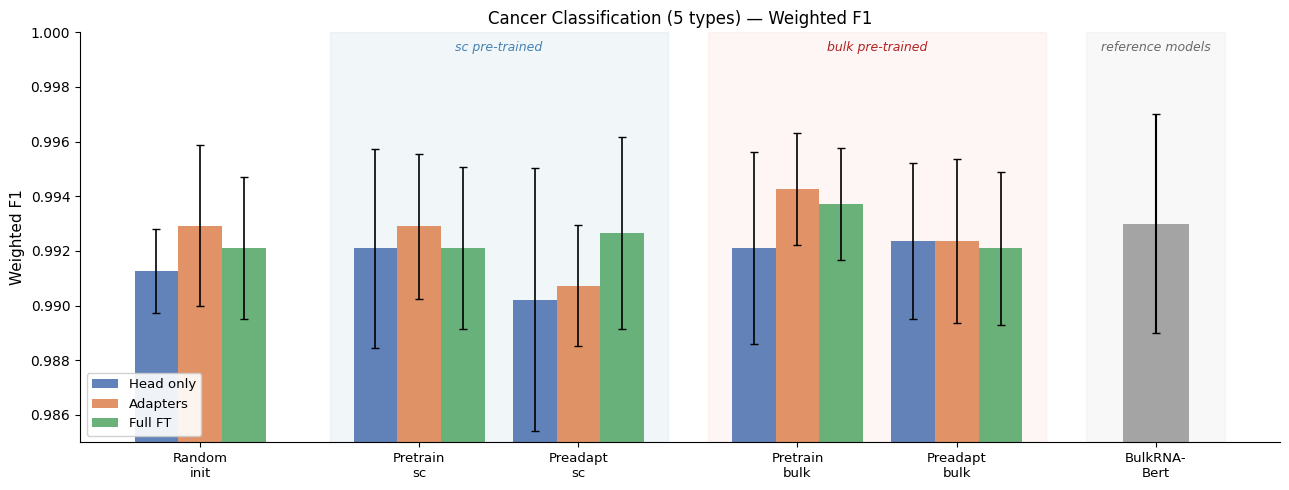

In [49]:
task = "canc_type_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}

dfs = {}
for mode in modes:
    df = pd.read_csv(f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv", comment="#")
    dfs[mode] = df.set_index("model")

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}
brnabert_x = 4.8

fig, ax = plt.subplots(figsize=(13, 5))

added = set()
for m_idx, mode in enumerate(modes):
    offset = (m_idx - 1) * bar_w
    for model, xc in centers.items():
        mean = dfs[mode].loc[model, "f1_weighted_mean"]
        std  = dfs[mode].loc[model, "f1_weighted_std"]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

# BulkRNABert reference bar
ax.bar(brnabert_x, bulkrnabert_weighted_f1_mean, bar_w * 1.5, yerr=bulkrnabert_weighted_f1_sd, capsize=3,
       color="#999999", alpha=0.88, label="_nolegend_")

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo,  ref_hi  = brnabert_x - 0.35, brnabert_x + 0.35
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)
ax.axvspan(ref_lo,  ref_hi,  alpha=0.05, color="gray",      zorder=0)

y_lim = (0.985, 1)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.0003, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.0003, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2,   y_lim[1] - 0.0003, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos    = list(centers.values()) + [brnabert_x]
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
               "Pretrain\nbulk", "Preadapt\nbulk", "BulkRNA-\nBert"]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=9.5)

ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Cancer Classification (5 types) — Weighted F1", fontsize=12)
ax.legend(loc="lower left", fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Cancer classification (33 types)

In [50]:
bulkrnabert_weighted_f1_mean = 0.942
bulkrnabert_weighted_f1_sd = 0.004
bulkformer_weighted_f1_mean = 0.833
geneformer_weighted_f1_mean = 0.473
genecompass_weighted_f1_mean = 0.761
scgpt_weighted_f1_mean = 0.83
scfoundation_weighted_f1_mean = 0.791
sclong_weighted_f1_mean = 0.347

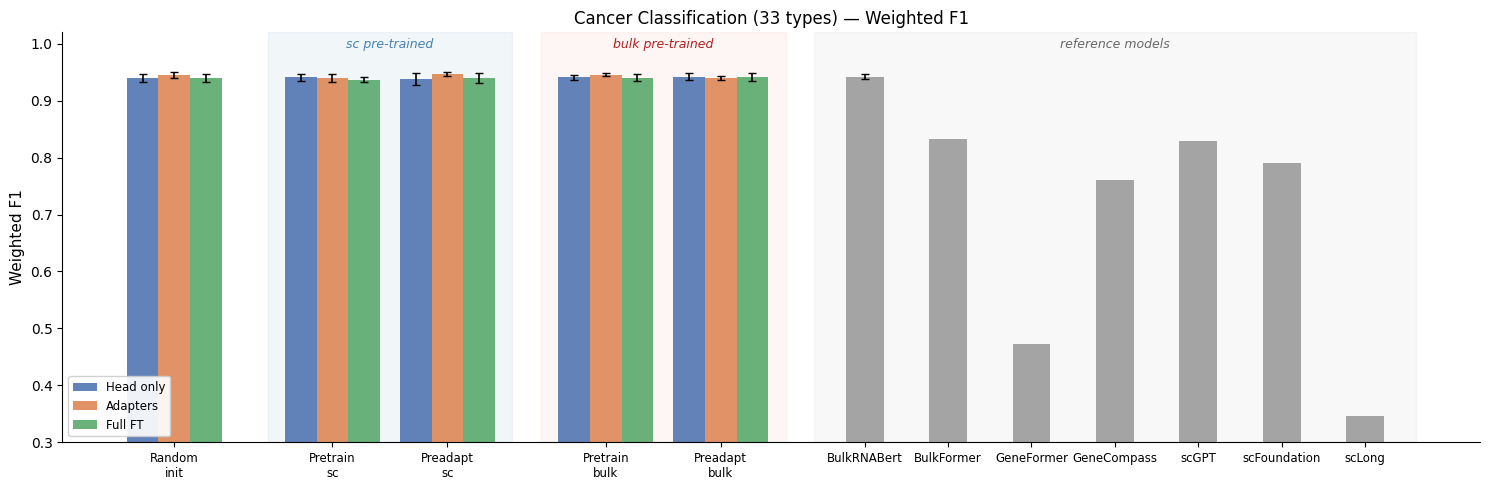

In [51]:
task = "canc_type_class_33"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}

dfs = {}
for mode in modes:
    df = pd.read_csv(f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv", comment="#")
    dfs[mode] = df.set_index("model")

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

ref_models = [
    ("BulkRNABert",  bulkrnabert_weighted_f1_mean,  bulkrnabert_weighted_f1_sd),
    ("BulkFormer",   bulkformer_weighted_f1_mean,   None),
    ("GeneFormer",   geneformer_weighted_f1_mean,   None),
    ("GeneCompass",  genecompass_weighted_f1_mean,  None),
    ("scGPT",        scgpt_weighted_f1_mean,        None),
    ("scFoundation", scfoundation_weighted_f1_mean, None),
    ("scLong",       sclong_weighted_f1_mean,        None),
]
ref_start, ref_spacing = 4.8, 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))

added = set()
for m_idx, mode in enumerate(modes):
    offset = (m_idx - 1) * bar_w
    for model, xc in centers.items():
        mean = dfs[mode].loc[model, "f1_weighted_mean"]
        std  = dfs[mode].loc[model, "f1_weighted_std"]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, yerr=sd, color="#999999",
           capsize=3, alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2} if sd else {})

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo,  ref_hi  = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)
ax.axvspan(ref_lo,  ref_hi,  alpha=0.05, color="gray",      zorder=0)

y_lim = (0.3, 1.02)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.01, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.01, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2,   y_lim[1] - 0.01, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos    = list(centers.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
               "Pretrain\nbulk", "Preadapt\nbulk"] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)

ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Cancer Classification (33 types) — Weighted F1", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Deconvolution

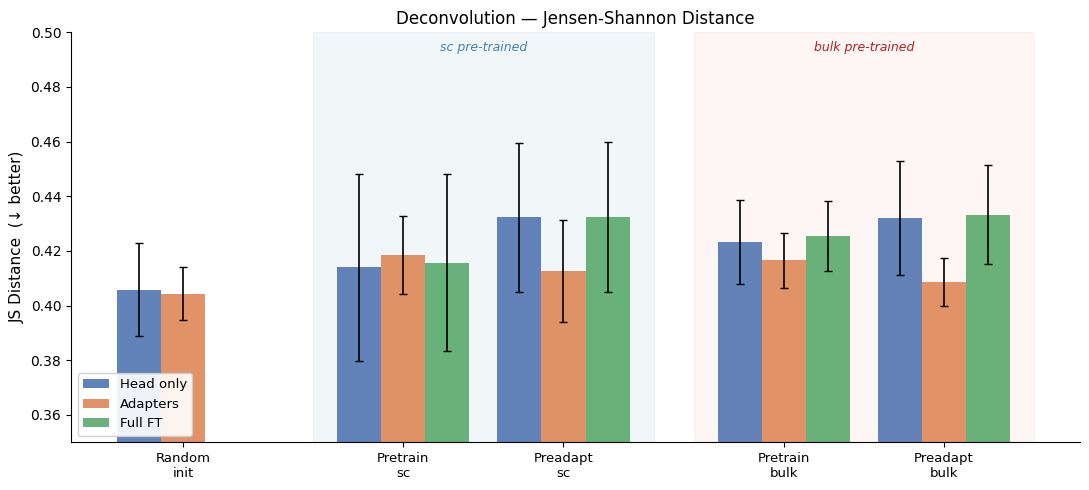

In [52]:
task = "deconv"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}

model_keys  = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "js_distance_mean"
metric_std  = "js_distance_std"

def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
             for m in model_keys
             if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")]
    return pd.concat(parts).set_index("model") if parts else None

dfs = {mode: load_mode(mode) for mode in modes}

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

fig, ax = plt.subplots(figsize=(11, 5))

added = set()
for m_idx, mode in enumerate(modes):
    offset = (m_idx - 1) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index:
            continue
        mean = df.loc[model, metric_mean]
        std  = df.loc[model, metric_std]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)

y_lim = (0.35, 0.50)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.003, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")

ax.set_xticks(list(centers.values()))
ax.set_xticklabels(["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
                    "Pretrain\nbulk", "Preadapt\nbulk"], fontsize=9.5)

ax.set_ylabel("JS Distance  (↓ better)", fontsize=11)
ax.set_title("Deconvolution — Jensen-Shannon Distance", fontsize=12)
ax.legend(loc="lower left", fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Disease classification

In [53]:
bulkformer_weighted_f1_mean = 0.939
geneformer_weighted_f1_mean = 0.749
genecompass_weighted_f1_mean = 0.882
scgpt_weighted_f1_mean = 0.885
scfoundation_weighted_f1_mean = 0.874
sclong_weighted_f1_mean = 0.81

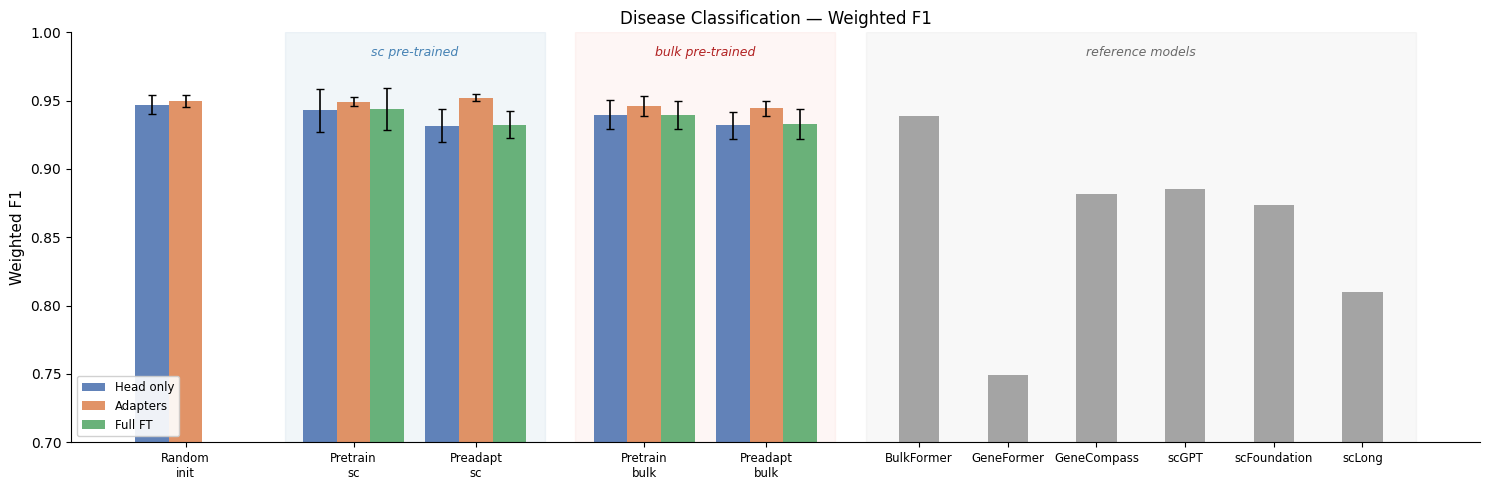

In [54]:
task = "disease_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]

def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
             for m in model_keys
             if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")]
    return pd.concat(parts).set_index("model") if parts else None

dfs = {mode: load_mode(mode) for mode in modes}

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

ref_models = [
    ("BulkFormer",   bulkformer_weighted_f1_mean,   None),
    ("GeneFormer",   geneformer_weighted_f1_mean,   None),
    ("GeneCompass",  genecompass_weighted_f1_mean,  None),
    ("scGPT",        scgpt_weighted_f1_mean,        None),
    ("scFoundation", scfoundation_weighted_f1_mean, None),
    ("scLong",       sclong_weighted_f1_mean,        None),
]
ref_start, ref_spacing = 4.8, 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))

added = set()
for m_idx, mode in enumerate(modes):
    offset = (m_idx - 1) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index:
            continue
        mean = df.loc[model, "f1_weighted_mean"]
        std  = df.loc[model, "f1_weighted_std"]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, color="#999999",
           alpha=0.88, label="_nolegend_")

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo,  ref_hi  = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)
ax.axvspan(ref_lo,  ref_hi,  alpha=0.05, color="gray",      zorder=0)

y_lim = (0.7, 1)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.01, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.01, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2,   y_lim[1] - 0.01, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos    = list(centers.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
               "Pretrain\nbulk", "Preadapt\nbulk"] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)

ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Disease Classification — Weighted F1", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Drug response prediction

In [2]:
bulkformer_pcc_mean = 0.91
geneformer_pcc_mean = 0.873
genecompass_pcc_mean = 0.872
scgpt_pcc_mean = 0.877
scfoundation_pcc_mean = 0.88
sclong_pcc_mean = 0.843

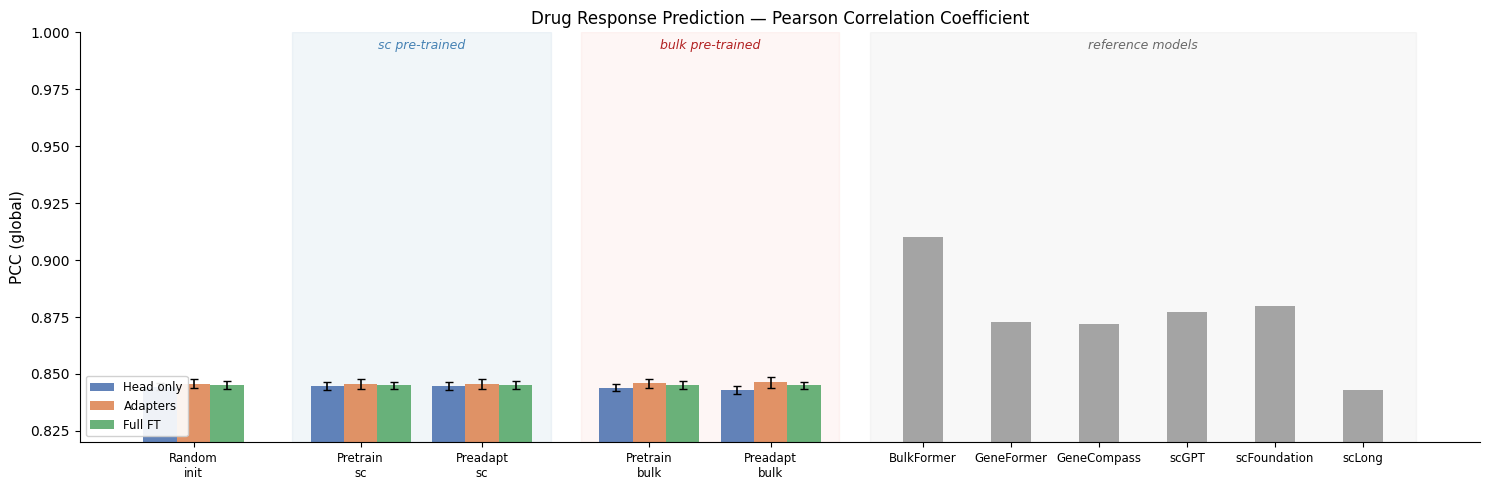

In [3]:
task = "drug_resp"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "global_pcc_mean"
metric_std  = "global_pcc_std"

def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
             for m in model_keys
             if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")]
    return pd.concat(parts).set_index("model") if parts else None

dfs = {mode: load_mode(mode) for mode in modes}

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

ref_models = [
    ("BulkFormer",   bulkformer_pcc_mean,   None),
    ("GeneFormer",   geneformer_pcc_mean,   None),
    ("GeneCompass",  genecompass_pcc_mean,  None),
    ("scGPT",        scgpt_pcc_mean,        None),
    ("scFoundation", scfoundation_pcc_mean, None),
    ("scLong",       sclong_pcc_mean,        None),
]
ref_start, ref_spacing = 4.8, 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))

added = set()
for m_idx, mode in enumerate(modes):
    offset = (m_idx - 1) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index:
            continue
        mean = df.loc[model, metric_mean]
        std  = df.loc[model, metric_std]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, color="#999999",
           alpha=0.88, label="_nolegend_")

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo,  ref_hi  = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)
ax.axvspan(ref_lo,  ref_hi,  alpha=0.05, color="gray",      zorder=0)

y_lim = (0.82, 1)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.003, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2,   y_lim[1] - 0.003, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos    = list(centers.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
               "Pretrain\nbulk", "Preadapt\nbulk"] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)

ax.set_ylabel("PCC (global)", fontsize=11)
ax.set_title("Drug Response Prediction — Pearson Correlation Coefficient", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Gene essentiality prediction

In [57]:
bulkformer_pcc_mean = 0.931
geneformer_pcc_mean = 0.897
genecompass_pcc_mean = 0.881
scgpt_pcc_mean = 0.907
scfoundation_pcc_mean = 0.852
sclong_pcc_mean = 0.889

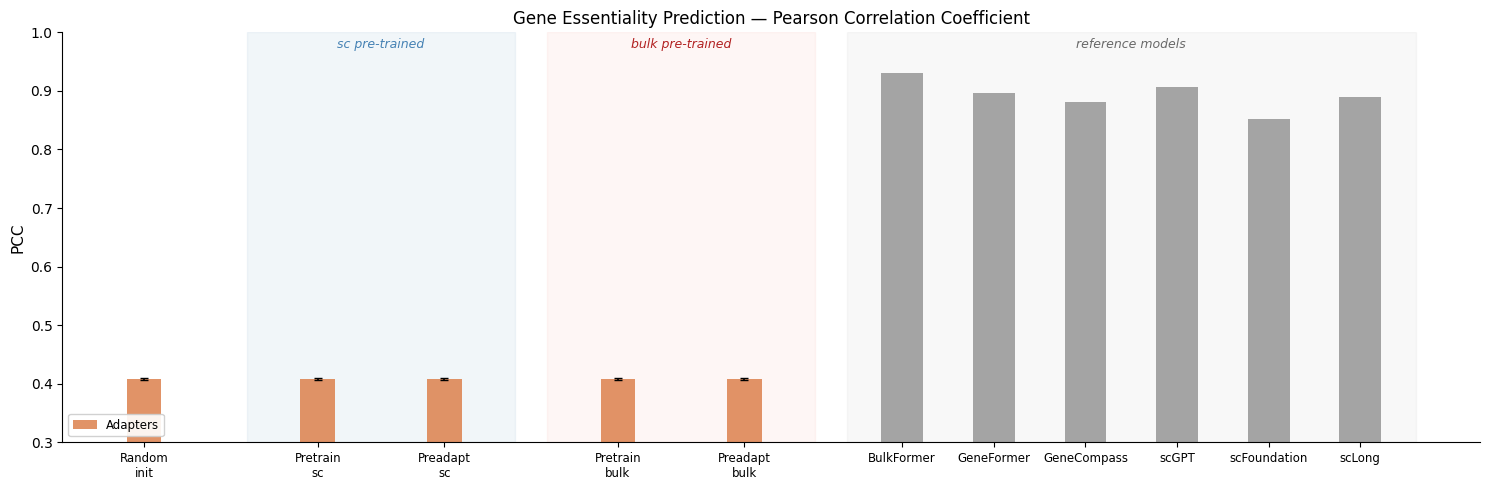

In [58]:
task = "gene_essent"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "test_pcc_mean"
metric_std  = "test_pcc_std"

def load_mode(mode):
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
             for m in model_keys
             if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")]
    return pd.concat(parts).set_index("model") if parts else None

dfs = {mode: load_mode(mode) for mode in modes}

bar_w = 0.22
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}

ref_models = [
    ("BulkFormer",   bulkformer_pcc_mean,   None),
    ("GeneFormer",   geneformer_pcc_mean,   None),
    ("GeneCompass",  genecompass_pcc_mean,  None),
    ("scGPT",        scgpt_pcc_mean,        None),
    ("scFoundation", scfoundation_pcc_mean, None),
    ("scLong",       sclong_pcc_mean,        None),
]
ref_start, ref_spacing = 4.8, 0.58
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(15, 5))

added = set()
for m_idx, mode in enumerate(modes):
    offset = (m_idx - 1) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index:
            continue
        mean = df.loc[model, metric_mean]
        std  = df.loc[model, metric_std]
        lbl  = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, color="#999999",
           alpha=0.88, label="_nolegend_")

sc_lo,   sc_hi   = centers["pretrain_sc"]  - 0.45, centers["preadapt_sc"]  + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ref_lo,  ref_hi  = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(sc_lo,   sc_hi,   alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon",    zorder=0)
ax.axvspan(ref_lo,  ref_hi,  alpha=0.05, color="gray",      zorder=0)

y_lim = (0.3, 1.0)
ax.set_ylim(*y_lim)

ax.text((sc_lo + sc_hi) / 2,     y_lim[1] - 0.01, "sc pre-trained",
        ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.01, "bulk pre-trained",
        ha="center", va="top", fontsize=9, color="firebrick", style="italic")
ax.text((ref_lo + ref_hi) / 2,   y_lim[1] - 0.01, "reference models",
        ha="center", va="top", fontsize=9, color="dimgray", style="italic")

tick_pos    = list(centers.values()) + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc",
               "Pretrain\nbulk", "Preadapt\nbulk"] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)

ax.set_ylabel("PCC", fontsize=11)
ax.set_title("Gene Essentiality Prediction — Pearson Correlation Coefficient", fontsize=12)
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Survival prediction

In [ ]:
bulkformer_auroc_mean = 0.747
geneformer_auroc_mean = 0.647
genecompass_auroc_mean = 0.709
scgpt_auroc_mean = 0.723
scfoundation_auroc_mean = 0.726
sclong_auroc_mean = 0.584